# Quickstart: 1D dissolution fronts with `from_mf6`

This quickstart reproduces the classic Engesgaard & Kipp (1992) benchmark: a
one-dimensional column initially filled with water in equilibrium with
**calcite** is flushed by an inflowing **MgCl$_2$** solution. The incoming
water dissolves calcite and briefly precipitates **dolomite**, producing a set
of sharp, migrating mineral fronts.

It also shows the recommended **transport-first workflow**: you build an
ordinary MODFLOW 6 flow + (single, conservative) transport model with FloPy,
then hand it to :meth:`~mf6rtm.mup3d.base.Mup3d.from_mf6`, which clones the
tracer transport model into one reactive transport model per chemical
component and couples it to PhreeqcRM.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy

from mf6rtm import utils, mup3d

# Resolve paths whether executed from the notebook dir or the repo root.
BASE = "." if os.path.isdir("data") else os.path.join("docs", "tutorials")
DATA = os.path.join(BASE, "data")

## 1. Spatial and temporal discretization

A 0.5 m column split into 50 cells, simulated for 0.24 days.

In [2]:
length_units = "meters"
time_units = "days"

nlay, nrow, ncol = 1, 1, 50
Lx = 0.5
delr = Lx / ncol
delc = 1.0
top, botm = 0.0, -1.0

k11 = 1.0            # hydraulic conductivity (m/d)
prsity = 0.32        # porosity
dispersivity = 0.0067  # longitudinal dispersivity (m)

q = 0.259            # injection rate at the inlet (m3/d)

perlen = 0.24        # simulation length (days)
tstep = 0.01
nstp = int(perlen / tstep)
tdis_rc = [(perlen, nstp, 1.0)]

## 2. Build the flow + tracer transport model with FloPy

We build a single **conservative tracer** GWT model. The inlet well carries a
`tracer` auxiliary variable; ``from_mf6`` uses that boundary to inject the
inflow solution's chemistry once the model becomes reactive.

In [3]:
sim_ws = os.path.join(BASE, "_tutorial01_run")
sim = flopy.mf6.MFSimulation(sim_name="quickstart", sim_ws=sim_ws, exe_name="mf6")
flopy.mf6.ModflowTdis(sim, nper=1, perioddata=tdis_rc, time_units=time_units)

# --- GWF flow model ---
gwf = flopy.mf6.ModflowGwf(sim, modelname="gwf", save_flows=True)
ims_gwf = flopy.mf6.ModflowIms(sim, linear_acceleration="CG", filename="gwf.ims")
sim.register_ims_package(ims_gwf, ["gwf"])

flopy.mf6.ModflowGwfdis(
    gwf, length_units=length_units, nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc, top=top, botm=botm, filename="gwf.dis",
)
flopy.mf6.ModflowGwfnpf(gwf, save_specific_discharge=True, icelltype=1, k=k11,
                        save_saturation=True, filename="gwf.npf")
flopy.mf6.ModflowGwfic(gwf, strt=1.0, filename="gwf.ic")

# constant head at the outlet (last column)
flopy.mf6.ModflowGwfchd(
    gwf, stress_period_data=[[(0, 0, ncol - 1), 1.0]],
    pname="chd", filename="gwf.chd",
)
# injection well at the inlet, carrying a tracer auxiliary
flopy.mf6.ModflowGwfwel(
    gwf, stress_period_data=[[(0, 0, 0), q, 1.0]],
    auxiliary=["tracer"], pname="wel", filename="gwf.wel",
)
flopy.mf6.ModflowGwfoc(
    gwf, head_filerecord="gwf.hds", budget_filerecord="gwf.cbb",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

# --- GWT conservative tracer model (template for from_mf6) ---
gwt = flopy.mf6.ModflowGwt(sim, modelname="gwt")
ims_gwt = flopy.mf6.ModflowIms(sim, linear_acceleration="BICGSTAB", filename="gwt.ims")
sim.register_ims_package(ims_gwt, ["gwt"])

flopy.mf6.ModflowGwtdis(
    gwt, length_units=length_units, nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc, top=top, botm=botm, filename="gwt.dis",
)
flopy.mf6.ModflowGwtic(gwt, strt=0.0, filename="gwt.ic")
flopy.mf6.ModflowGwtssm(gwt, sources=[["wel", "aux", "tracer"]], filename="gwt.ssm")
flopy.mf6.ModflowGwtadv(gwt, scheme="UPSTREAM")
flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=dispersivity, ath1=0.0,
                        filename="gwt.dsp")
flopy.mf6.ModflowGwtmst(gwt, porosity=prsity, filename="gwt.mst")
flopy.mf6.ModflowGwtoc(
    gwt, concentration_filerecord="gwt.ucn",
    saverecord=[("CONCENTRATION", "ALL")],
)
flopy.mf6.ModflowGwfgwt(sim, exgtype="GWF6-GWT6", exgmnamea="gwf",
                        exgmnameb="gwt", filename="gwf-gwt.gwfgwt")

package_name = gwf-gwt.gwfgwt
filename = gwf-gwt.gwfgwt
package_type = gwfgwt
model_or_simulation_package = simulation
simulation_name = quickstart


## 3. Define the geochemistry

mf6rtm expresses PHREEQC chemistry as ``mup3d`` classes. For each input you
(1) load the data (here from CSV via a ``utils`` helper), (2) wrap it in the
matching class, and (3) call ``.set_ic(...)`` to place it — an integer *zone
number* for uniform chemistry, or a ``(nlay, nrow, ncol)`` array to vary it in
space. The object is then given to the model: ``Solutions`` goes into
``from_mf6``; the phases are attached with ``set_*`` methods.

**Solutions** — the aqueous waters. Column ``1`` is the background pore water
(placed everywhere with ``set_ic(1)``); column ``2`` is the inflow water the
boundary ``ChemStress`` injects.

In [4]:
solutionsdf = pd.read_csv(os.path.join(DATA, "tut01_solutions.csv"),
                          comment="#", index_col=0)
solutions = utils.solution_df_to_dict(solutionsdf)
solution = mup3d.Solutions(solutions)
solution.set_ic(1)  # background solution everywhere
solutionsdf

,sol_bck,sol_in
comp,,
pH,9.910000,7.000
pe,4.000000,4.000
C(+4),0.000123,0.000
Ca,0.000123,0.000
Cl,0.000000,0.002
Mg,0.000000,0.001


**Equilibrium phases** — minerals held at equilibrium each step (PHREEQC
``EQUILIBRIUM_PHASES``): calcite and dolomite. ``set_ic(1)`` applies the same
assemblage to every cell.

In [5]:
eqp_df = pd.read_csv(os.path.join(DATA, "tut01_equilibrium_phases.csv"))
eqp_dict = utils.parse_equilibriums_dataframe(eqp_df)
equilibrium_phases = mup3d.EquilibriumPhases(eqp_dict)
equilibrium_phases.set_ic(1)
eqp_df

,phase,sat_index,conc_mol_lb,num
0,Calcite,0.0,0.000122,1
1,Dolomite,0.0,0.000000,1


## 4. Couple chemistry to the MF6 model with `from_mf6`

``from_mf6`` reads the grid from the GWF model and stores the tracer GWT model
as the template that will be cloned per component.

In [6]:
model = mup3d.Mup3d.from_mf6(sim, solution, name="quickstart", gwt_name="gwt")
model.set_wd(sim_ws)
model.set_database(os.path.join(DATA, "pht3d_datab.dat"))
model.set_equilibrium_phases(equilibrium_phases)
model.set_postfix(os.path.join(DATA, "tut01_postfix.phqr"))
model.initialize()

Using temperatue of 25.0 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Min concentration: None (no clipping)
  Reactions calculated at all time steps
Phreeqc initialized


but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.


## 5. Assign the inflow chemistry to the boundary

The `wel` package injects solution 2 (the MgCl$_2$ water). ``type='aux'``
routes it through the GWF stress package + GWT SSM.

In [7]:
wellchem = mup3d.ChemStress("wel", type="aux")
wellchem.set_spd([2])
model.set_chem_stress(wellchem)

Initializing ChemStress
ChemStress wel initialized


## 6. Write and run the reactive transport simulation

In [8]:
model.write_simulation()

# Stage the platform's MODFLOW 6 binaries (mf6 + libmf6) into the run directory
# so the solver finds the shared library locally. pixi fetches them into
# ``benchmark/bin`` via the ``install-benchmark-bins`` task.
utils.prep_bins(model.wd, src_path=os.path.join(BASE, "..", "..", "benchmark", "bin"))

model.run()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_1...
  writing solution package ims_2...
  writing solution package ims_3...
  writing solution package ims_4...
  writing solution package ims_5...
  writing solution package ims_6...
  writing solution package ims_7...
  writing package H.gwfgwt...
  writing package O.gwfgwt...
  writing package Charge.gwfgwt...
  writing package C.gwfgwt...
  writing package Ca.gwfgwt...
  writing package Cl.gwfgwt...
  writing package Mg.gwfgwt...
  writing model gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package wel...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    

Using libmf6 found in model directory: libmf6.dylib


Processing initial chemistry configuration
Starting Solution at 2026-07-18 09:49:28
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   2.08e-06 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   2.56e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.50e-06 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   5.06e-05 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.48e-06 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   4.95e-05 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   1.43e-06 sec
Reactions       | Stress period:  1     | Time step:      4          | Completed in :  0 min   4.70e-05 sec
Transport       | Stress period:  1     | Time step:

but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.
but is not in solution or other phases.



MODEL RUN FINISHED BUT CHECK THE RESULTS

Solution finished at 2026-07-18 09:49:28. Running time:  0.0030139 mins


True

## 7. Results

Read the selected-output table and plot the aqueous species and mineral
amounts along the column at the final time.

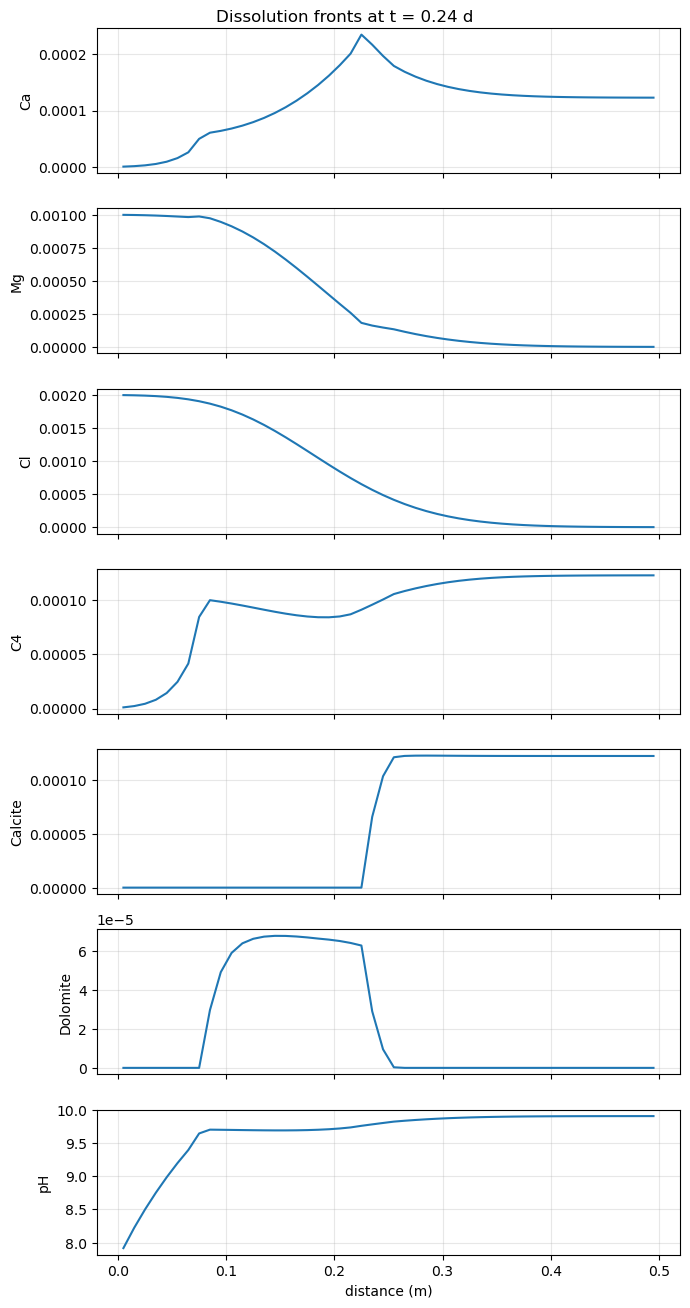

In [9]:
sout = pd.read_csv(os.path.join(model.wd, "sout.csv"))
sout["x"] = (sout["col"] - 0.5) * delr           # cell-center distance (m)
final = sout[sout["time_d"] == sout["time_d"].max()]

plot_vars = ["Ca", "Mg", "Cl", "C4", "Calcite", "Dolomite", "pH"]

fig, axs = plt.subplots(len(plot_vars), 1, figsize=(7, 1.9 * len(plot_vars)),
                        sharex=True)
for ax, var in zip(axs, plot_vars):
    ax.plot(final["x"], final[var], color="tab:blue")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)
axs[-1].set_xlabel("distance (m)")
fig.suptitle("Dissolution fronts at t = %.2f d" % sout["time_d"].max())
fig.tight_layout()